In [1]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [2]:
AL_SETUP = {
    'HAR': (3,300),
    'WISDM': (5,40),
    'UWAVE' : (3,25)
}

In [3]:
DATASET = 'HAR'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [4]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

Filtered Files:	 ['har/Random_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ASER_cycle_3_per_300_har.csv', 'har/TypiClust_ASER_cycle_3_per_300_har.csv', 'har/Random_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ER_cycle_3_per_300_har.csv']


## Uncertainty and Random

In [5]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,1,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
2,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
3,1,0,3,77.57,66.26,77.57,67.73,79.53,66.90,78.05,66.29
4,1,1,4,88.42,90.46,87.67,87.23,87.62,86.38,88.06,92.61
5,1,2,5,91.38,95.38,92.95,90.57,94.55,93.27,90.97,96.79
6,2,0,6,87.11,61.02,87.92,69.28,87.89,62.62,89.73,62.67
7,2,1,7,91.51,83.39,91.45,88.45,90.22,80.45,88.10,85.83
8,2,2,8,92.54,85.02,90.88,89.75,91.96,89.10,89.40,91.52


['Random-ER', 'Random-ASER']


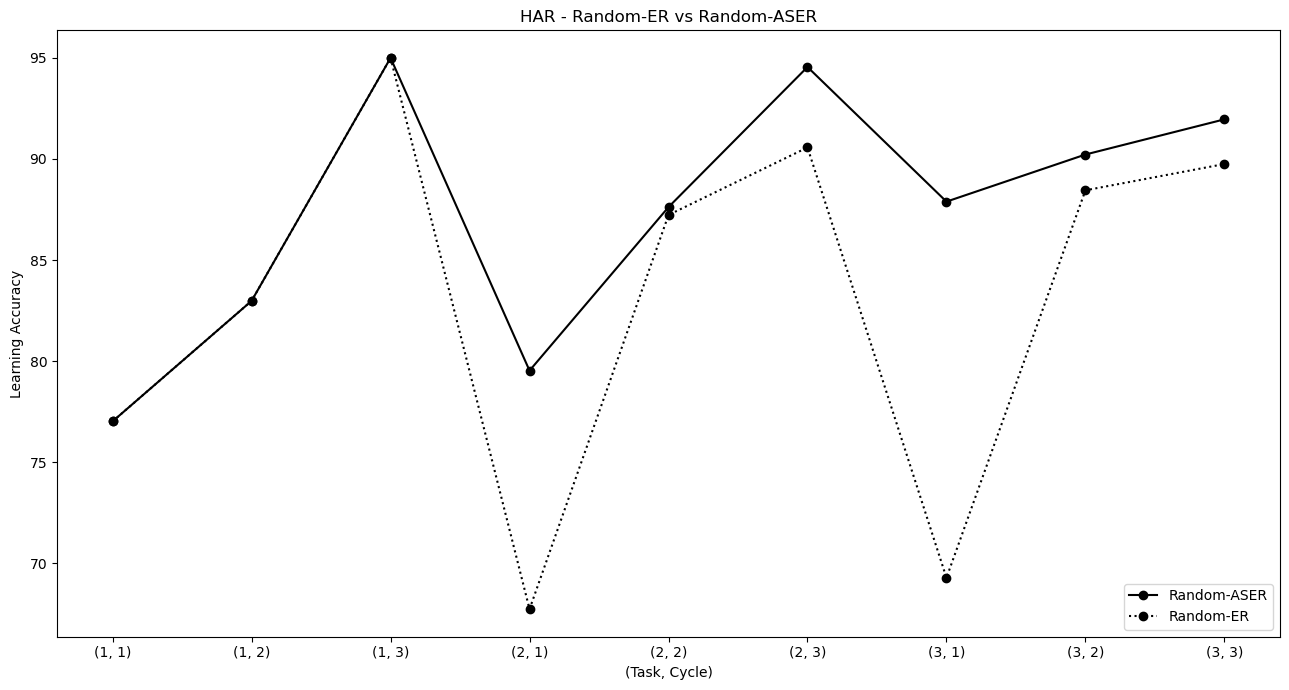

In [6]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


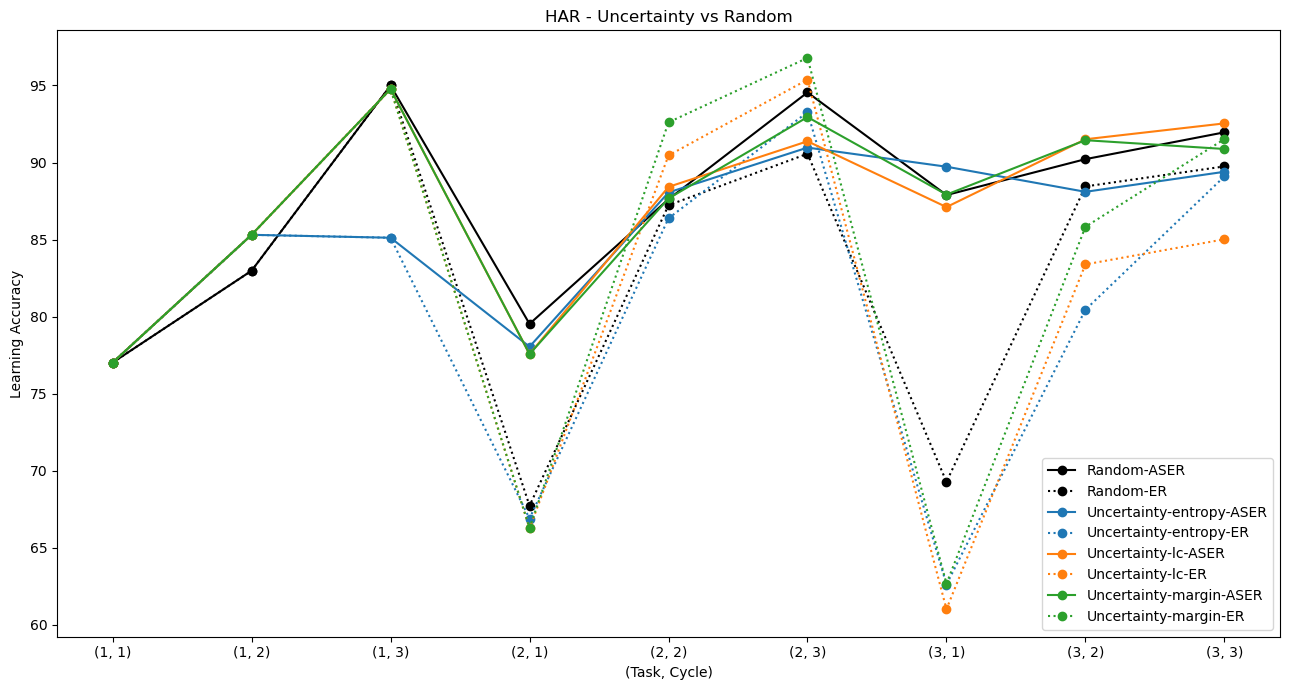

In [7]:
pu.plot_progress(
    df=uncert_la, 
    loc='lower right',
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

In [8]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,1,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
2,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
3,1,0,3,80.34,52.69,80.34,58.08,78.84,52.77,78.90,52.70
4,1,1,4,80.60,75.49,80.05,80.92,82.84,66.55,80.13,76.77
5,1,2,5,78.85,76.36,73.76,81.99,84.32,70.86,80.08,76.67
6,2,0,6,58.21,67.17,60.94,64.82,64.28,63.56,60.76,62.56
7,2,1,7,55.81,69.66,62.18,67.33,61.89,68.80,60.68,71.53
8,2,2,8,57.46,70.21,62.57,70.23,63.01,71.50,61.10,72.16


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


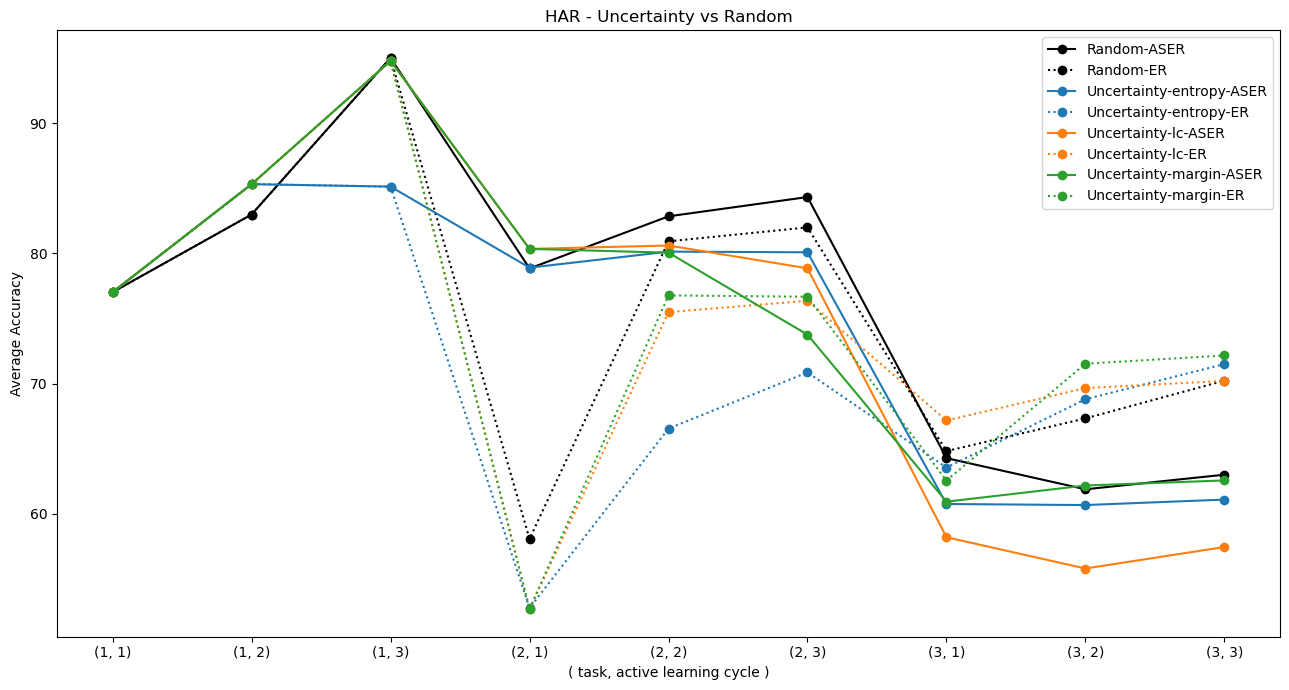

In [9]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="( task, active learning cycle )", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


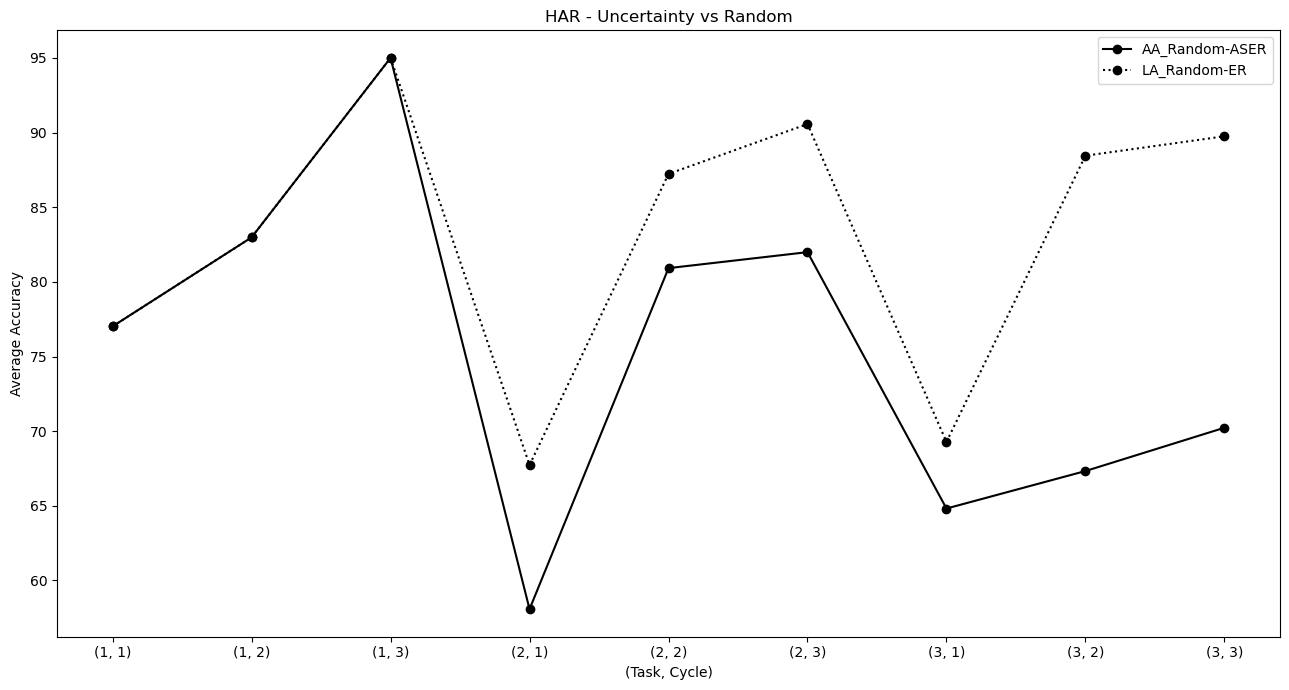

In [10]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [11]:
uncer_aa_task = pu.task_level_filter(uncert_aa)
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
1,1,2,5,78.85,76.36,73.76,81.99,84.32,70.86,80.08,76.67
2,2,2,8,57.46,70.21,62.57,70.23,63.01,71.50,61.10,72.16


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


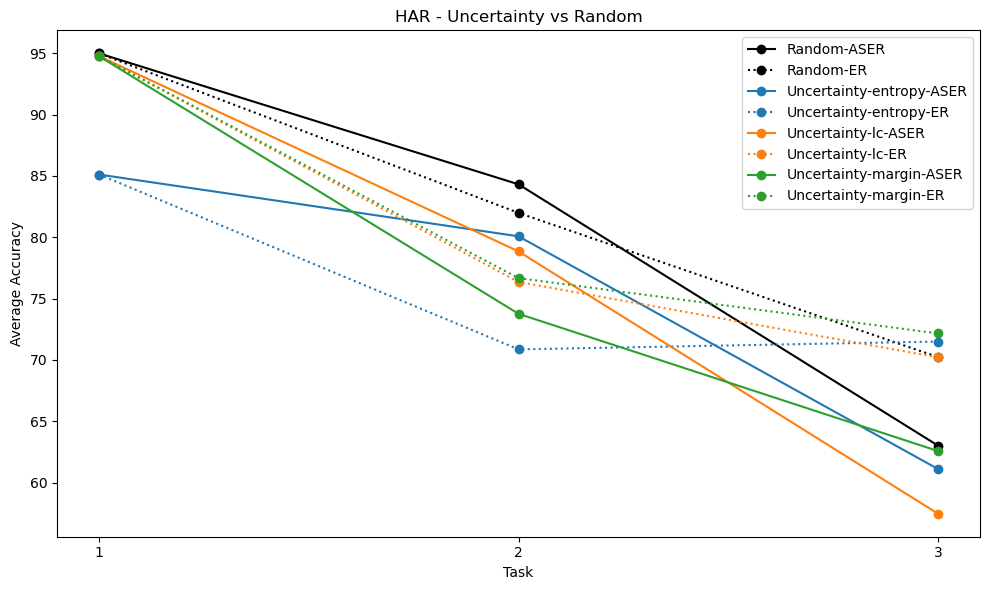

In [12]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [13]:
uncer_la_task = pu.task_level_filter(uncert_la)
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
1,1,2,5,91.38,95.38,92.95,90.57,94.55,93.27,90.97,96.79
2,2,2,8,92.54,85.02,90.88,89.75,91.96,89.10,89.40,91.52


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


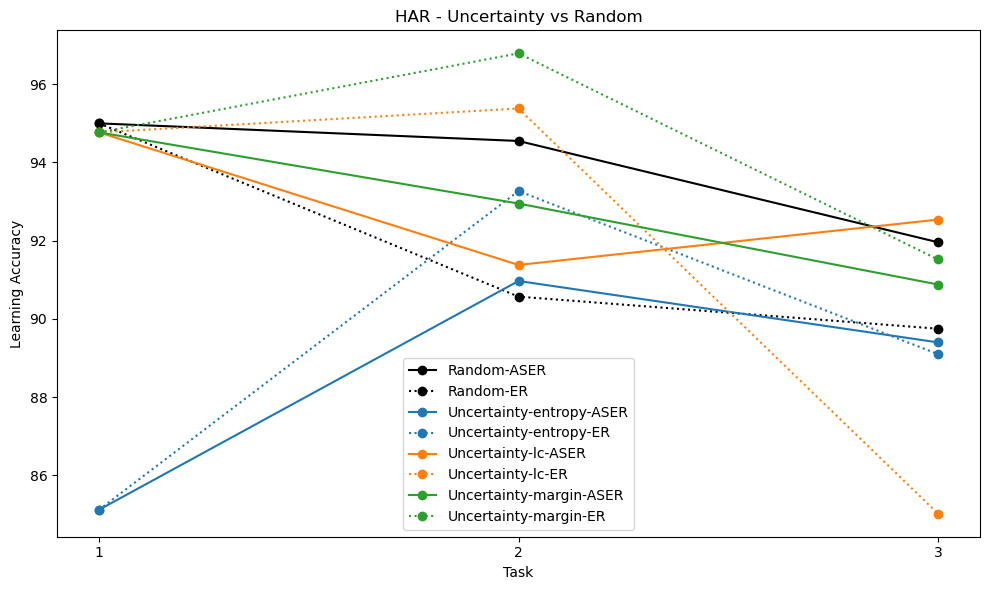

In [14]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [15]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,91.55,91.55
1,84.32,81.99,77.56,74.63
2,63.01,70.23,60.38,71.29


In [16]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,91.55,91.55
1,94.55,90.57,91.77,95.15
2,91.96,89.75,90.94,88.55


# Diversity-based methods